In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [7]:
# https://www.kaggle.com/datasets/mirichoi0218/insurance
df = pd.read_csv("medical_cost_personal.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.shape

(1338, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

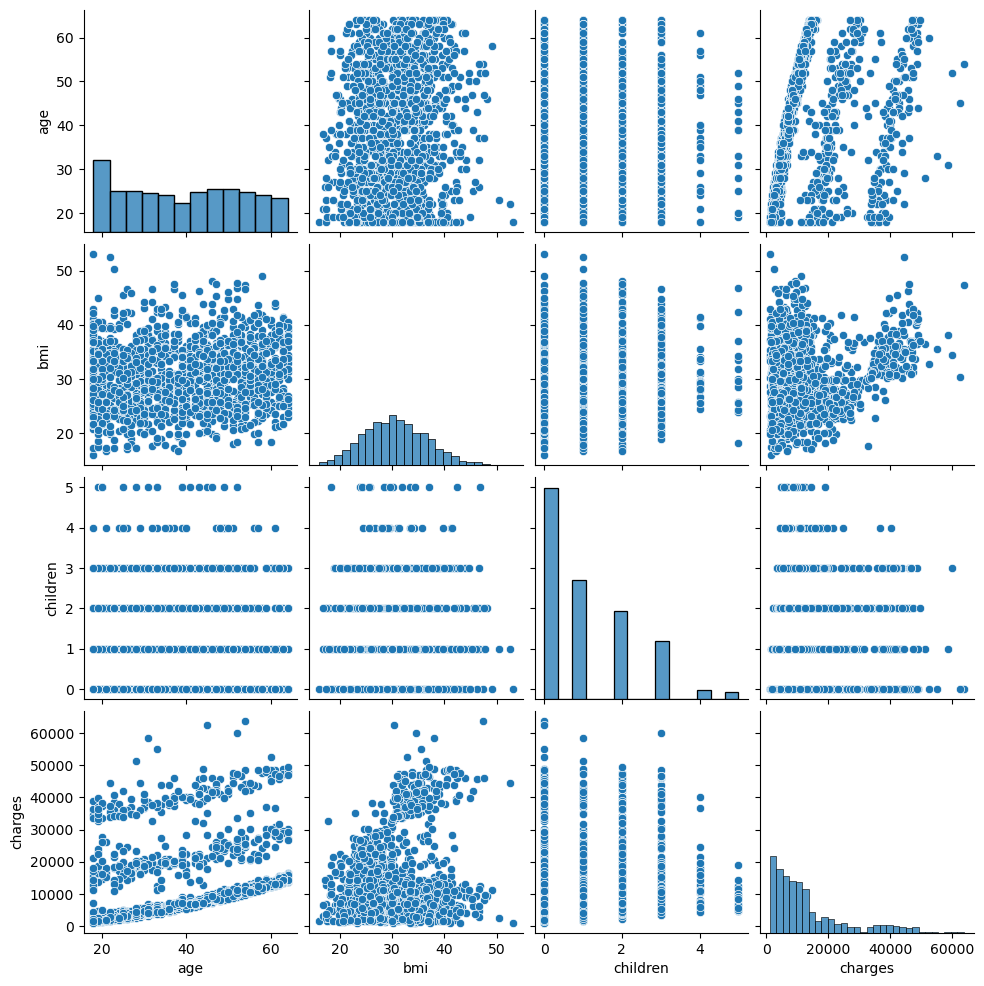

In [17]:
# Visualization

sns.pairplot(df)
plt.show()

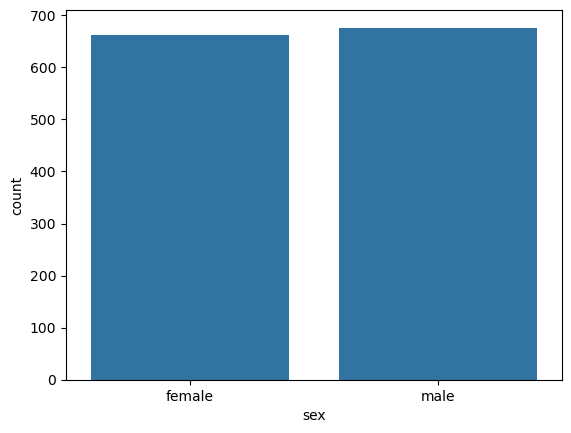

In [18]:
sns.countplot(data=df, x="sex")
plt.show()

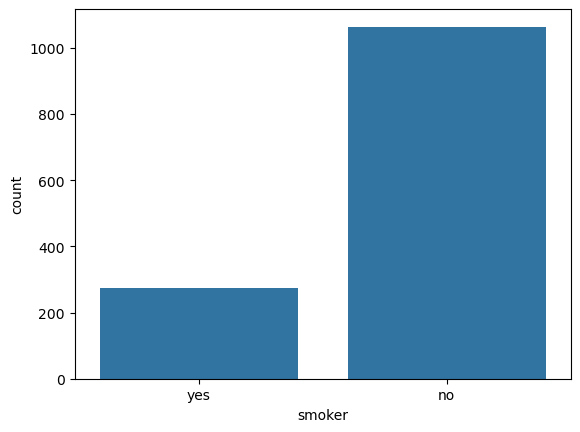

In [19]:
sns.countplot(data=df, x="smoker")
plt.show()

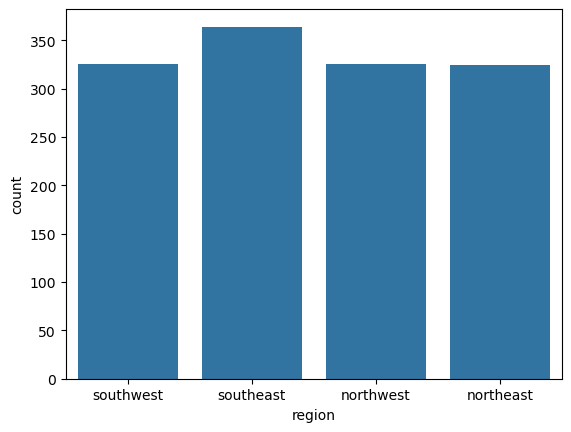

In [20]:
sns.countplot(data=df, x="region")
plt.show()

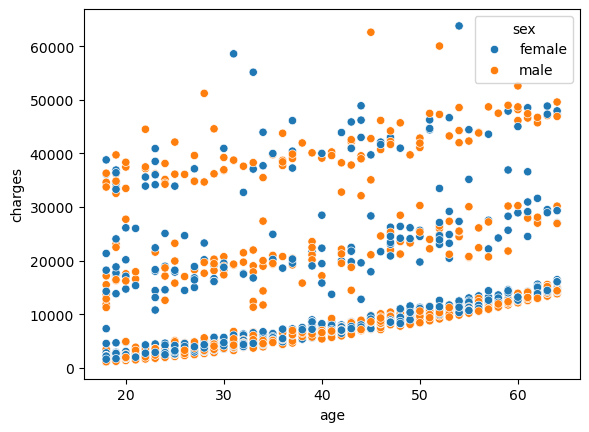

In [21]:
sns.scatterplot(data=df, x="age", y="charges", hue="sex")
plt.show()

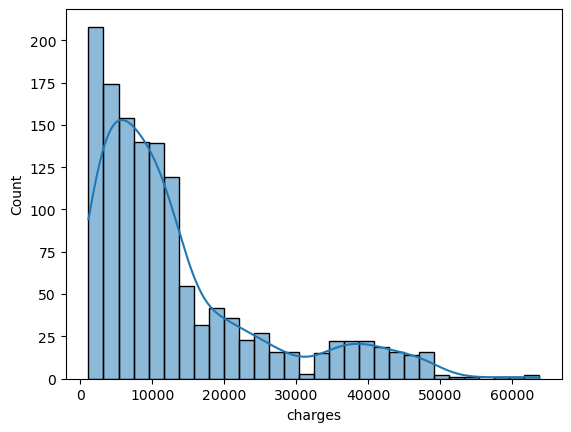

In [24]:
sns.histplot(data=df, x="charges", kde=True)
plt.show()

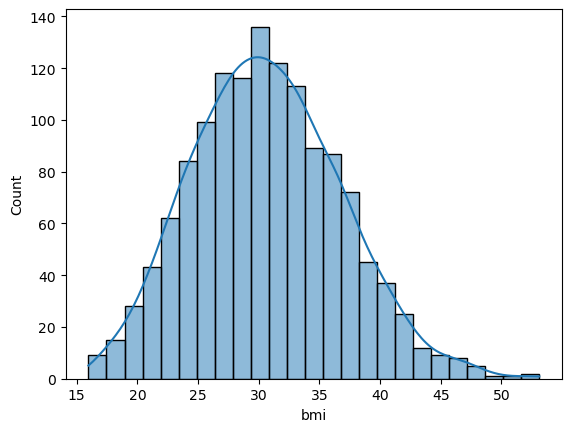

In [23]:
sns.histplot(data=df, x="bmi", kde=True)
plt.show()

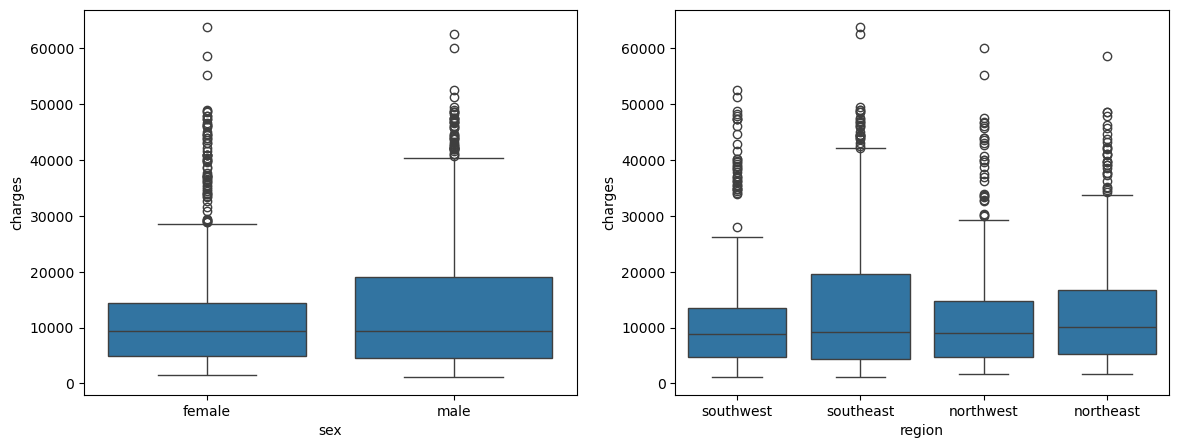

In [32]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, x="sex", y="charges")

plt.subplot(1,2,2)
sns.boxplot(data=df, x="region", y="charges")

plt.show()

In [33]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [34]:
# encoding

df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.90,0,1,southwest,16884.9240
1,18,0,33.77,1,0,southeast,1725.5523
2,28,0,33.00,3,0,southeast,4449.4620


In [36]:
from sklearn.model_selection import train_test_split

X = df.drop("charges", axis = 1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [38]:
# one-hot encoding --> region

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ["region"]

transformer = ColumnTransformer(
    transformers= [
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ], remainder="passthrough"
)

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [42]:
from lightgbm import LGBMRegressor

In [43]:
model = LGBMRegressor()

In [44]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 8
[LightGBM] [Info] Start training from score 13374.181390


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [45]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R2 Score: ", score)

R2 Score:  0.871843376594573


In [46]:
# hyperparameter tuning

params = {
    "n_estimators": [100,200,300],
    "learning_rate": [0.01,0.1],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 5, 10],
    "min_child_samples": [10,20,30],
    "subsample": [0.6,0.8,1.0],
    "colsample_bytree": [0.6,0.8,1.0],
    "reg_alpha": [0,0.5,1.0],
    "reg_lambda": [0,0.5,1.0]
}

In [47]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import RandomizedSearchCV

In [49]:
random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(verbosity=-1),
    param_distributions=params,
    cv=5,
    verbose=0,
    random_state=15,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [50]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=LGBMRegressor(verbosity=-1), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.1],
                                        'max_depth': [-1, 5, 10],
                                        'min_child_samples': [10, 20, 30],
                                        'n_estimators': [100, 200, 300],
                                        'num_leaves': [31, 50, 70],
                                        'reg_alpha': [0, 0.5, 1.0],
                                        'reg_lambda': [0, 0.5, 1.0],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=15, scoring='neg_root_mean_squared_error')

In [51]:
random_search.best_params_

{'subsample': 0.6,
 'reg_lambda': 1.0,
 'reg_alpha': 0.5,
 'num_leaves': 50,
 'n_estimators': 100,
 'min_child_samples': 30,
 'max_depth': -1,
 'learning_rate': 0.1,
 'colsample_bytree': 0.6}

In [52]:
y_pred = random_search.predict(X_test)
print("Score: ",r2_score(y_test, y_pred))

Score:  0.891597805845849


In [62]:
# With Transformation - Only Target Value
# dependent feature' imizin (yani target=y) normal dağılımda olması regresyon problemlerinde daha iyi sonuç verebilmektedir, ağaç bazlı regresyon 
# algoritmalarında fark yaratmayabilir. Hem transformation yapıp hemde normal şekilde deneme yaparark bu değerlendirilebilir.

In [55]:
from scipy.stats import boxcox

y_train_transformed, lambda_y = boxcox(y_train)

In [56]:
y_train_transformed

array([15.21106982, 10.76906508, 14.18387955, ..., 13.82797268,
       12.12777291, 12.48181972], shape=(1003,))

In [57]:
lambda_y

np.float64(0.06257002294810683)

In [58]:
model = LGBMRegressor(verbosity=-1)
model.fit(X_train, y_train_transformed)

LGBMRegressor(verbosity=-1)

In [59]:
y_pred_transformed = model.predict(X_test)
print("Score: ",r2_score(y_test, y_pred_transformed)) # yanlış kullanım, inverse boxcox kullanacağız

Score:  -1.1637044969953472


In [60]:
# Transformation Notebook 

# (inverse Box-Cox)
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

# original scaling of predictions
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [61]:
print("Score: ",r2_score(y_test, y_pred_original))

Score:  0.8925898035961266
